In [2]:
df = pd.read_csv(FILE, encoding='utf-8-sig', low_memory=False)
df.columns = df.columns.str.strip()

print(f'Total navios : {len(df):,}')
print(f'DWT          : {df["dwt"].isna().mean()*100:.1f}% nulos — calado INDISPONÍVEL')
print(f'LOA nulos    : {df["loa"].isna().sum()} ({df["loa"].isna().mean()*100:.1f}%)')
print(f'beam nulos   : {df["beam"].isna().sum()} ({df["beam"].isna().mean()*100:.1f}%)')

# Outlier ZIM NORFOLK
outlier_mask = df['loa'] > 400
print(f'\nOutlier LOA > 400m: {outlier_mask.sum()} navio(s)')
print(df[outlier_mask][['NOME DO NAVIO','SHIPPING LINE','loa','beam','CAPACIDADE (TEU)']])
print('-> Excluído das métricas (erro de dados)')

df_clean = df[~outlier_mask].copy()

# Missing por carrier
miss  = df_clean[df_clean['loa'].isna()].groupby('SHIPPING LINE').size().rename('sem_loa')
total = df_clean.groupby('SHIPPING LINE').size().rename('total')
miss_df = pd.concat([miss, total], axis=1).fillna(0)
miss_df['sem_loa'] = miss_df['sem_loa'].astype(int)
miss_df['pct_missing'] = (miss_df['sem_loa'] / miss_df['total'] * 100).round(1)
print('\nMissing LOA/beam por carrier:')
print(miss_df.sort_values('pct_missing', ascending=False))

Total navios : 1,378
DWT          : 100.0% nulos — calado INDISPONÍVEL
LOA nulos    : 335 (24.3%)
beam nulos   : 335 (24.3%)

Outlier LOA > 400m: 1 navio(s)
     NOME DO NAVIO SHIPPING LINE    loa  beam  CAPACIDADE (TEU)
1361   ZIM NORFOLK           ZIM  661.0  22.0              9200
-> Excluído das métricas (erro de dados)

Missing LOA/beam por carrier:
               sem_loa  total  pct_missing
SHIPPING LINE                             
COSCO               97    335         29.0
CMA CGM             66    231         28.6
EVERGREEN           36    142         25.4
MAERSK              58    261         22.2
MSC                 46    220         20.9
Hapag-Lloyd         19    100         19.0
ONE                  9     58         15.5
ZIM                  4     30         13.3


In [3]:
PORTOS = {
    'Santos'    : {'loa': 366, 'beam': 51},
    'Itaguaí'   : {'loa': 366, 'beam': 51},
    'Paranaguá' : {'loa': 300, 'beam': 40},
    'Suape'     : {'loa': 300, 'beam': 40},
    'Pecém'     : {'loa': 280, 'beam': 40},
    'Manaus'    : {'loa': 200, 'beam': 30},
}

print(f'{"Porto":12s}  {"LOA max":>8s}  {"Beam max":>9s}')
for p, r in PORTOS.items():
    print(f'{p:12s}  {r["loa"]:>7.0f}m  {r["beam"]:>8.0f}m')
print('\nNota: calado nao disponivel (DWT=0 no dataset)')

Porto          LOA max   Beam max
Santos            366m        51m
Itaguaí           366m        51m
Paranaguá         300m        40m
Suape             300m        40m
Pecém             280m        40m
Manaus            200m        30m

Nota: calado nao disponivel (DWT=0 no dataset)


In [4]:
results = []
for porto, limites in PORTOS.items():
    for _, row in df_clean.iterrows():
        loa_v  = row['loa']
        beam_v = row['beam']
        teu    = row['CAPACIDADE (TEU)'] if not pd.isna(row['CAPACIDADE (TEU)']) else 0

        if pd.isna(loa_v) or pd.isna(beam_v):
            status = 'indeterminado'
        elif loa_v > limites['loa'] or beam_v > limites['beam']:
            status = 'incompativel'
        else:
            status = 'compativel'

        results.append({
            'porto'  : porto,
            'carrier': row['SHIPPING LINE'],
            'teu'    : teu,
            'status' : status,
        })

res = pd.DataFrame(results)
print(f'Registos classificados: {len(res):,}')
print(res['status'].value_counts())

Registos classificados: 8,262
status
compativel       3896
incompativel     2356
indeterminado    2010
Name: count, dtype: int64


In [5]:
pivot_total = res.groupby(['carrier','porto']).size().reset_index(name='total')
pivot_comp  = res[res['status']=='compativel'].groupby(['carrier','porto']).size().reset_index(name='n_comp')
pivot_indet = res[res['status']=='indeterminado'].groupby(['carrier','porto']).size().reset_index(name='n_indet')

matrix_base = pivot_total.merge(pivot_comp,  on=['carrier','porto'], how='left')
matrix_base = matrix_base.merge(pivot_indet, on=['carrier','porto'], how='left').fillna(0)
matrix_base['pct_comp']   = (matrix_base['n_comp']  / matrix_base['total'] * 100).round(1)
matrix_base['pct_indet']  = (matrix_base['n_indet'] / matrix_base['total'] * 100).round(1)
matrix_base['pct_incomp'] = (100 - matrix_base['pct_comp'] - matrix_base['pct_indet']).round(1).clip(lower=0)
matrix_base['n_det']      = matrix_base['total'] - matrix_base['n_indet']
matrix_base['pct_comp_det'] = np.where(
    matrix_base['n_det'] > 0,
    (matrix_base['n_comp'] / matrix_base['n_det'] * 100).round(1), np.nan)

porto_order  = ['Manaus','Pecém','Suape','Paranaguá','Santos','Itaguaí']
heatmap_data = matrix_base.pivot(index='carrier', columns='porto', values='pct_comp_det')[porto_order]

print('% Navios compatíveis (sobre navios com LOA/beam conhecidos):')
print(heatmap_data.round(1))

% Navios compatíveis (sobre navios com LOA/beam conhecidos):
porto        Manaus  Pecém  Suape  Paranaguá  Santos  Itaguaí
carrier                                                      
CMA CGM        42.4   59.4   63.0       63.0    84.8     84.8
COSCO          38.7   59.7   63.0       63.0    79.8     79.8
EVERGREEN       9.4   34.9   35.8       35.8    87.7     87.7
Hapag-Lloyd    13.6   32.1   42.0       42.0    79.0     79.0
MAERSK         43.3   73.9   76.8       76.8    86.2     86.2
MSC            27.6   43.7   48.9       48.9    81.0     81.0
ONE            42.9   57.1   57.1       57.1    93.9     93.9
ZIM            53.8   57.7   57.7       57.7   100.0    100.0


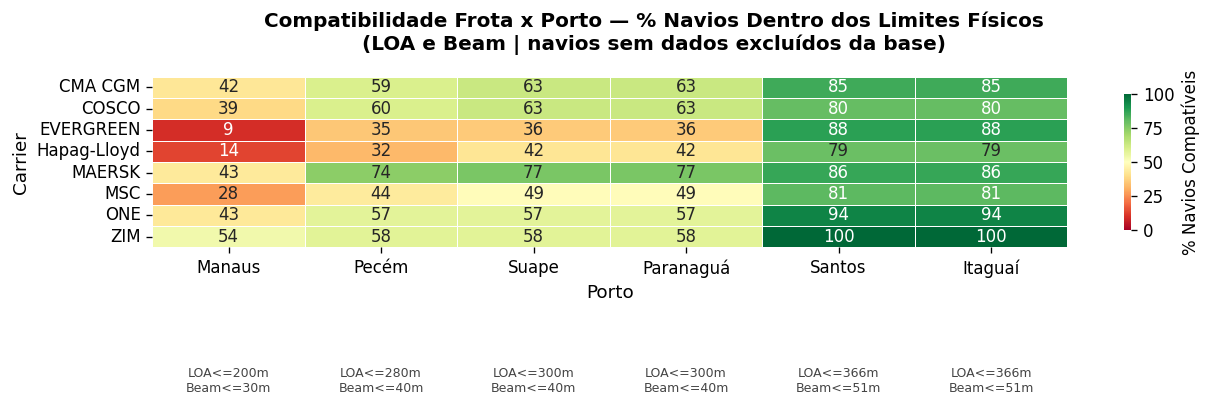

In [6]:
fig, ax = plt.subplots(figsize=(11, 6))
fig.suptitle(
    'Compatibilidade Frota x Porto — % Navios Dentro dos Limites Físicos\n'
    '(LOA e Beam | navios sem dados excluídos da base)',
    fontsize=12, fontweight='bold')

mask = heatmap_data.isna()
cmap = sns.color_palette("RdYlGn", as_cmap=True)

sns.heatmap(
    heatmap_data, annot=True, fmt='.0f', cmap=cmap,
    vmin=0, vmax=100, linewidths=0.5, linecolor='white',
    mask=mask, ax=ax,
    cbar_kws={'label': '% Navios Compatíveis', 'shrink': 0.8})

for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        if mask.iloc[i, j]:
            ax.add_patch(plt.Rectangle((j,i),1,1,fill=True,color='#cccccc',zorder=2))
            ax.text(j+0.5, i+0.5, 'N/D', ha='center', va='center',
                    fontsize=9, color='#666', zorder=3)

for idx, porto in enumerate(porto_order):
    ax.text(idx+0.5, -0.7,
            f"LOA<={PORTOS[porto]['loa']}m\nBeam<={PORTOS[porto]['beam']}m",
            ha='center', va='top', fontsize=7.5, color='#444',
            transform=ax.get_xaxis_transform())

ax.set_xlabel('Porto', fontsize=11)
ax.set_ylabel('Carrier', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout(rect=[0,0.05,1,1])
plt.show()

In [7]:
teu_block = (res[res['status']=='incompativel']
               .groupby(['carrier','porto'])['teu']
               .sum().reset_index(name='teu_bloqueado'))

teu_total_c = (res[res['porto']=='Santos']
                 .groupby('carrier')['teu']
                 .sum().reset_index(name='teu_total'))

teu_block = teu_block.merge(teu_total_c, on='carrier', how='left')
teu_block['pct_teu_bloqueado'] = (teu_block['teu_bloqueado'] / teu_block['teu_total'] * 100).round(1)

portos_rest = ['Manaus','Pecém','Suape','Paranaguá']
ranking = (teu_block[teu_block['porto'].isin(portos_rest)]
            .groupby('carrier')['teu_bloqueado'].sum()
            .reset_index().sort_values('teu_bloqueado', ascending=False))
ranking = ranking.merge(teu_total_c, on='carrier', how='left')
ranking['rank'] = range(1, len(ranking)+1)

print('Ranking TEU bloqueado em portos restritivos (Manaus+Pecém+Suape+Paranaguá):')
print(ranking[['rank','carrier','teu_bloqueado','teu_total']].to_string(index=False))
print('\nNota: teu_bloqueado = soma por porto (mesmo navio conta N vezes se bloqueado em N portos)')

Ranking TEU bloqueado em portos restritivos (Manaus+Pecém+Suape+Paranaguá):
 rank     carrier  teu_bloqueado  teu_total
    1         MSC        5731152    2573411
    2       COSCO        4175096    2695370
    3     CMA CGM        3494700    1507176
    4   EVERGREEN        3193739    1257964
    5 Hapag-Lloyd        2735981    1085870
    6      MAERSK        2693966    1837143
    7         ONE        1179842     723697
    8         ZIM         531342     301466

Nota: teu_bloqueado = soma por porto (mesmo navio conta N vezes se bloqueado em N portos)


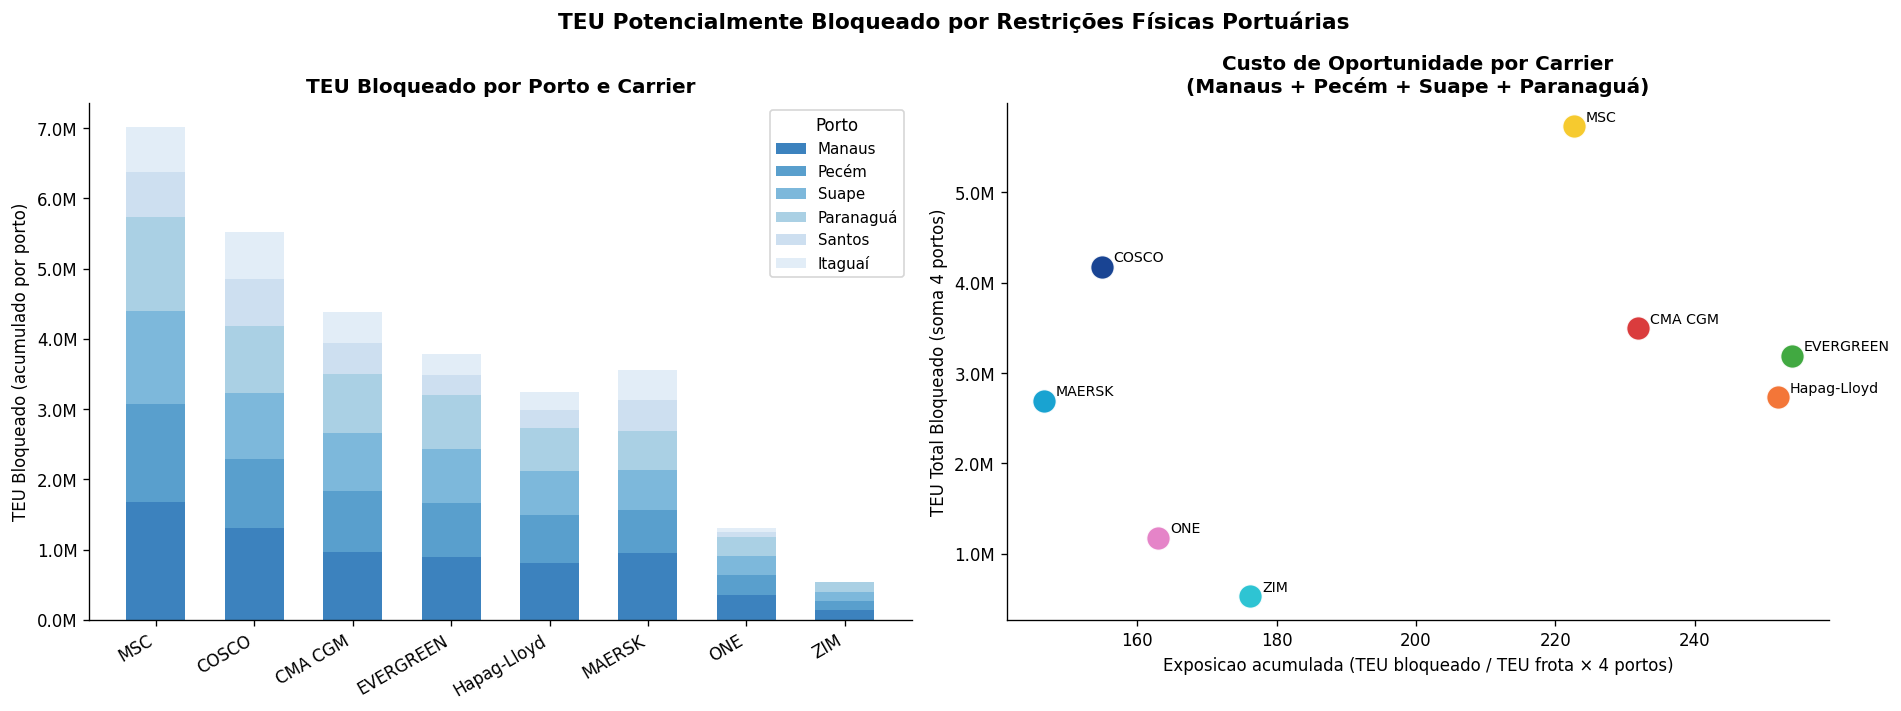

In [8]:
teu_pivot = teu_block.pivot(index='carrier', columns='porto', values='teu_bloqueado').fillna(0)
teu_pivot = teu_pivot[[p for p in porto_order if p in teu_pivot.columns]]
teu_pivot = teu_pivot.loc[ranking['carrier'].tolist()]

porto_colors = ['#2171B5','#4292C6','#6BAED6','#9ECAE1','#C6DBEF','#DEEBF7']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('TEU Potencialmente Bloqueado por Restrições Físicas Portuárias',
             fontsize=13, fontweight='bold')

x      = np.arange(len(teu_pivot))
bottom = np.zeros(len(teu_pivot))
for porto, color in zip(porto_order, porto_colors):
    if porto in teu_pivot.columns:
        vals = teu_pivot[porto].values
        ax1.bar(x, vals, bottom=bottom, color=color, alpha=0.88, label=porto, width=0.6)
        bottom += vals

ax1.set_xticks(x)
ax1.set_xticklabels(teu_pivot.index, rotation=30, ha='right')
ax1.set_ylabel('TEU Bloqueado (acumulado por porto)')
ax1.set_title('TEU Bloqueado por Porto e Carrier')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,p: f'{v/1e6:.1f}M'))
ax1.legend(fontsize=9, title='Porto')

for _, row in ranking.iterrows():
    c = row['carrier']
    pct = row['teu_bloqueado'] / row['teu_total'] * 100
    ax2.scatter(pct, row['teu_bloqueado'],
                s=200, color=CORES.get(c,'#888'),
                alpha=0.9, edgecolors='white', linewidth=0.8, zorder=3)
    ax2.annotate(c, (pct, row['teu_bloqueado']),
                 textcoords='offset points', xytext=(7,3), fontsize=8.5)

ax2.set_xlabel('Exposicao acumulada (TEU bloqueado / TEU frota × 4 portos)')
ax2.set_ylabel('TEU Total Bloqueado (soma 4 portos)')
ax2.set_title('Custo de Oportunidade por Carrier\n(Manaus + Pecém + Suape + Paranaguá)')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,p: f'{v/1e6:.1f}M'))
plt.tight_layout()
plt.show()

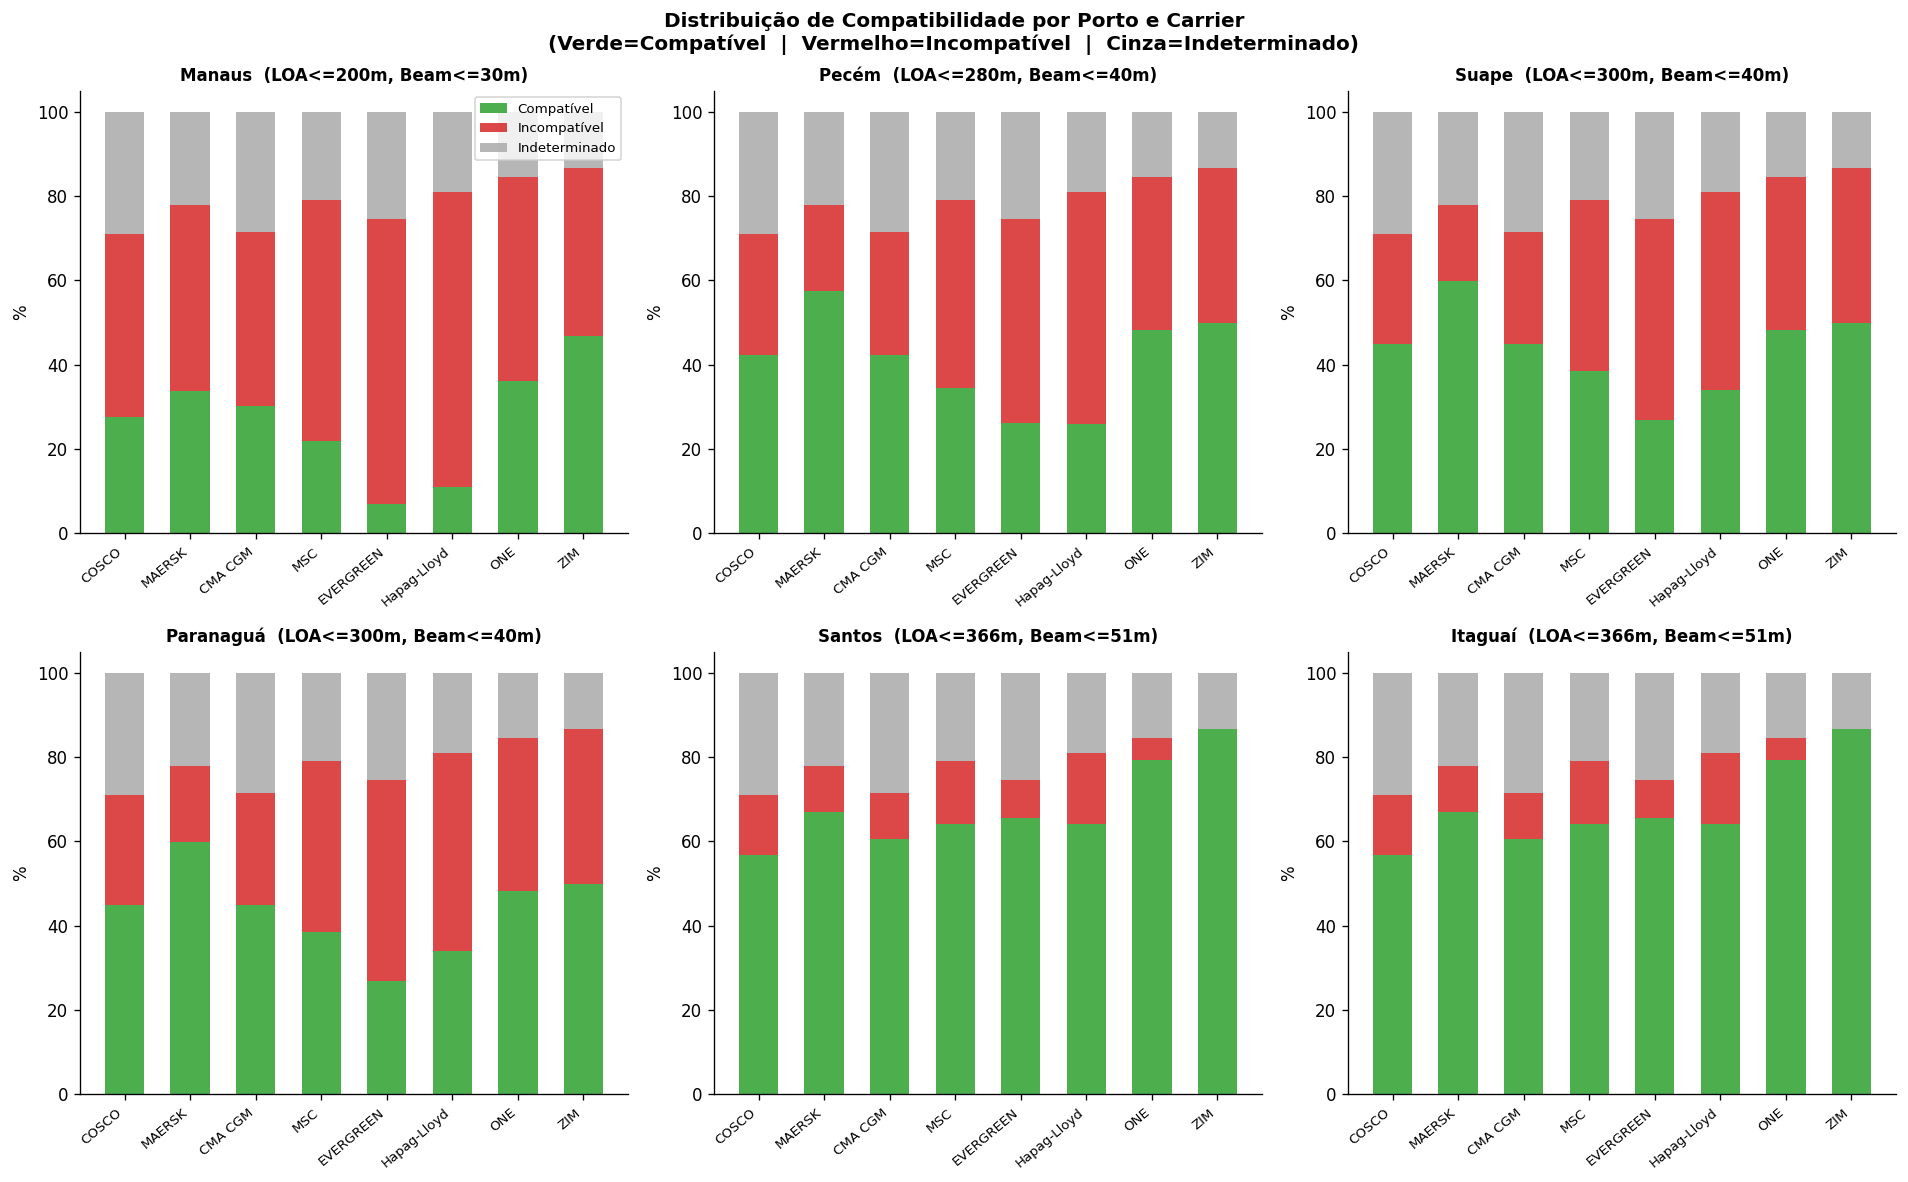

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(
    'Distribuição de Compatibilidade por Porto e Carrier\n'
    '(Verde=Compatível  |  Vermelho=Incompatível  |  Cinza=Indeterminado)',
    fontsize=12, fontweight='bold')

for idx, porto in enumerate(porto_order):
    ax  = axes.flatten()[idx]
    sub = matrix_base[matrix_base['porto']==porto].set_index('carrier')
    sub = sub.reindex([c for c in CORES.keys() if c in sub.index])
    x   = np.arange(len(sub))

    ax.bar(x, sub['pct_comp'],   color='#2CA02C', alpha=0.85, label='Compatível',    width=0.6)
    ax.bar(x, sub['pct_incomp'], color='#D62728', alpha=0.85, label='Incompatível',
           bottom=sub['pct_comp'], width=0.6)
    ax.bar(x, sub['pct_indet'],  color='#AAAAAA', alpha=0.85, label='Indeterminado',
           bottom=sub['pct_comp']+sub['pct_incomp'], width=0.6)

    ax.set_xticks(x)
    ax.set_xticklabels(sub.index, rotation=40, ha='right', fontsize=8)
    ax.set_title(f'{porto}  (LOA<={PORTOS[porto]["loa"]}m, Beam<={PORTOS[porto]["beam"]}m)',
                 fontsize=10)
    ax.set_ylim(0, 105)
    ax.set_ylabel('%')
    if idx == 0:
        ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

In [10]:
print('=' * 65)
print('SUMÁRIO — PORT INFRASTRUCTURE COMPATIBILITY')
print('=' * 65)
print()
print('LIMITAÇÕES:')
print('  1. Calado: DWT 100% nulo — draft NAO calculado')
print('  2. LOA/beam: 24.3% missing — classificados como indeterminado')
print('  3. Outlier excluído: ZIM NORFOLK LOA=661m (erro de dados)')
print('  4. Frota registada ANTAQ — nao deployment real')
print()
print('ACHADOS:')
print('  Manaus (LOA<=200m): EVERGREEN 9% compatível — maior restrição')
print('  Santos/Itaguaí: ZIM 100% compatível — frota dimensionada para estes portos')
print('  Hapag-Lloyd: 14% compatível em Manaus, 32% em Pecém')
print('  MSC: maior TEU absoluto bloqueado em portos restritivos')
print()
print('CONCLUSÃO:')
print('  Carriers com frotas de navios grandes (MSC, COSCO, ONE) têm')
print('  custo de oportunidade elevado nos portos do Norte/Nordeste.')
print('  ZIM e MAERSK têm perfil de frota mais compatível com a')
print('  infraestrutura portuária brasileira fora do eixo Sul-Sudeste.')

SUMÁRIO — PORT INFRASTRUCTURE COMPATIBILITY

LIMITAÇÕES:
  1. Calado: DWT 100% nulo — draft NAO calculado
  2. LOA/beam: 24.3% missing — classificados como indeterminado
  3. Outlier excluído: ZIM NORFOLK LOA=661m (erro de dados)
  4. Frota registada ANTAQ — nao deployment real

ACHADOS:
  Manaus (LOA<=200m): EVERGREEN 9% compatível — maior restrição
  Santos/Itaguaí: ZIM 100% compatível — frota dimensionada para estes portos
  Hapag-Lloyd: 14% compatível em Manaus, 32% em Pecém
  MSC: maior TEU absoluto bloqueado em portos restritivos

CONCLUSÃO:
  Carriers com frotas de navios grandes (MSC, COSCO, ONE) têm
  custo de oportunidade elevado nos portos do Norte/Nordeste.
  ZIM e MAERSK têm perfil de frota mais compatível com a
  infraestrutura portuária brasileira fora do eixo Sul-Sudeste.
